In [ ]:
import os
import re
import json
import time
import copy
import warnings

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
SEED = 1234
DATA_ROOT = os.environ.get("ML1M_DIR", "data")
ARTIFACT_DIR = "artifacts"
PRIOR_W = 5          # pseudo-ratings used to shrink user / movie means
SVD_DIMS = 20        # dimensions kept from the title TF-IDF
MAX_EPOCHS = 30
BATCH_SIZE = 4096
PATIENCE = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(ARTIFACT_DIR, exist_ok=True)
warnings.filterwarnings("ignore")
np.random.seed(SEED)
torch.manual_seed(SEED)

OCC_NAMES = {0: "other", 1: "academic/educator", 2: "artist", 3: "clerical/admin", 4: "college/grad student",
             5: "customer service", 6: "doctor/health care", 7: "executive/managerial", 8: "farmer",
             9: "homemaker", 10: "K-12 student", 11: "lawyer", 12: "programmer", 13: "retired",
             14: "sales/marketing", 15: "scientist", 16: "self-employed", 17: "technician/engineer",
             18: "tradesman/craftsman", 19: "unemployed", 20: "writer"}
AGE_LABELS = {1: "Under 18", 18: "18-24", 25: "25-34", 35: "35-44", 45: "45-49", 50: "50-55", 56: "56+"}
GENRE_LIST = ["Action", "Adventure", "Animation", "Children's", "Comedy", "Crime", "Documentary", "Drama",
              "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller",
              "War", "Western"]

In [ ]:
def find_dataset_dir(roots=None):
    needed = {"movies.dat", "users.dat", "ratings.dat"}
    for root in (roots or [DATA_ROOT, "/content", "."]):
        if not os.path.isdir(root):
            continue
        for folder, _, names in os.walk(root):
            if needed.issubset(names):
                return folder
    raise FileNotFoundError(
        f"movies.dat, users.dat and ratings.dat were not found under '{DATA_ROOT}' (or /content). "
        "Upload the three files to Colab's /content folder, or point ML1M_DIR at their location."
    )

In [ ]:
data_folder = find_dataset_dir()
print(f"Dataset folder: {data_folder}")

def read_dat(fname, cols, **kw):
    # ML-1M uses the two-character separator '::' and latin-1 text (accented titles)
    return pd.read_csv(os.path.join(data_folder, fname), sep="::", engine="python",
                       encoding="latin-1", names=cols, **kw)

ratings_df = read_dat("ratings.dat", ["UserID", "MovieID", "Rating", "Timestamp"])
users_df = read_dat("users.dat", ["UserID", "Gender", "Age", "Occupation", "Zip"], dtype={"Zip": str})
movies_df = read_dat("movies.dat", ["MovieID", "Title", "Genres"])

Dataset folder: /content


In [ ]:
for label, frame in {"ratings": ratings_df, "users": users_df, "movies": movies_df}.items():
    print(f"\n### {label}  ->  {frame.shape[0]} rows x {frame.shape[1]} cols")
    print(frame.head(3).to_string())
    print(frame.dtypes.to_string())
print("\nNumeric summary of ratings:\n", ratings_df[["Rating", "Timestamp"]].describe().to_string())


### ratings  ->  1000209 rows x 4 cols
   UserID  MovieID  Rating  Timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
UserID       int64
MovieID      int64
Rating       int64
Timestamp    int64

### users  ->  6040 rows x 5 cols
   UserID Gender  Age  Occupation    Zip
0       1      F    1          10  48067
1       2      M   56          16  70072
2       3      M   25          15  55117
UserID         int64
Gender        object
Age            int64
Occupation     int64
Zip           object

### movies  ->  3883 rows x 3 cols
   MovieID                    Title                        Genres
0        1         Toy Story (1995)   Animation|Children's|Comedy
1        2           Jumanji (1995)  Adventure|Children's|Fantasy
2        3  Grumpier Old Men (1995)                Comedy|Romance
MovieID     int64
Title      object
Genres     object

Numeric summary of ratings:
              Rating     Timestamp
count  1.0

In [ ]:
n_users_seen, n_movies_seen, n_rows = ratings_df.UserID.nunique(), ratings_df.MovieID.nunique(), len(ratings_df)
density = n_rows / (n_users_seen * n_movies_seen)
print(f"\nDistinct users: {n_users_seen} | distinct rated movies: {n_movies_seen} (catalogue size {len(movies_df)}) | rows: {n_rows}")
print(f"Sparsity of the user x movie matrix: {1 - density:.2%}")


Distinct users: 6040 | distinct rated movies: 3706 (catalogue size 3883) | rows: 1000209
Sparsity of the user x movie matrix: 95.53%


In [ ]:
star_share = ratings_df.Rating.value_counts(normalize=True).sort_index()
print("\nShare of each star rating:\n", star_share.round(3).to_string())
print(f"Average rating {ratings_df.Rating.mean():.3f} (std {ratings_df.Rating.std():.3f}); "
      f"{(ratings_df.Rating >= 4).mean():.1%} of ratings are 4 or 5 stars.")


Share of each star rating:
 Rating
1    0.056
2    0.108
3    0.261
4    0.349
5    0.226
Average rating 3.582 (std 1.117); 57.5% of ratings are 4 or 5 stars.


In [ ]:
by_user = ratings_df.groupby("UserID").size()
by_movie = ratings_df.groupby("MovieID").size()
for tag, s in (("user ", by_user), ("movie", by_movie)):
    print(f"Ratings per {tag}: min={s.min()}  median={s.median():.0f}  mean={s.mean():.1f}  max={s.max()}")

Ratings per user : min=20  median=96  mean=165.6  max=2314
Ratings per movie: min=1  median=124  mean=269.9  max=3428


In [ ]:
genre_freq = movies_df.Genres.str.split("|").explode().value_counts()
print("\nMovies per genre:\n", genre_freq.to_string())
print("Gender share among users:", users_df.Gender.value_counts(normalize=True).round(3).to_dict())
print("Users per age bucket:", users_df.Age.map(AGE_LABELS).value_counts().to_dict())


Movies per genre:
 Genres
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Fantasy          68
Western          68
Film-Noir        44
Gender share among users: {'M': 0.717, 'F': 0.283}
Users per age bucket: {'25-34': 2096, '35-44': 1193, '18-24': 1103, '45-49': 550, '50-55': 496, '56+': 380, 'Under 18': 222}


In [ ]:
joined = ratings_df.merge(users_df, on="UserID").merge(movies_df, on="MovieID")
print("\nAverage rating by gender:\n", joined.groupby("Gender").Rating.mean().round(3).to_string())
print("\nAverage rating by age bucket:\n", joined.groupby("Age").Rating.mean().rename(index=AGE_LABELS).round(3).to_string())


Average rating by gender:
 Gender
F    3.620
M    3.569

Average rating by age bucket:
 Age
Under 18    3.550
18-24       3.508
25-34       3.545
35-44       3.618
45-49       3.638
50-55       3.715
56+         3.767


In [ ]:
genre_avg = (joined.assign(Genre=joined.Genres.str.split("|")).explode("Genre")
             .groupby("Genre").Rating.agg(["mean", "count"]).sort_values("mean"))
print("\nAverage rating per genre (worst -> best):\n", genre_avg.round(3).to_string())
when = pd.to_datetime(ratings_df.Timestamp, unit="s")
print(f"\nRatings were logged between {when.min().date()} and {when.max().date()}; "
      f"{(when.dt.year == 2000).mean():.0%} of them in 2000.")


Average rating per genre (worst -> best):
               mean   count
Genre                     
Horror       3.215   76386
Children's   3.422   72186
Fantasy      3.447   36301
Sci-Fi       3.467  157294
Adventure    3.477  133953
Action       3.491  257457
Comedy       3.522  356580
Thriller     3.570  189680
Romance      3.607  147523
Western      3.638   20683
Musical      3.666   41533
Mystery      3.668   40178
Animation    3.685   43293
Crime        3.709   79541
Drama        3.766  354529
War          3.893   68527
Documentary  3.933    7910
Film-Noir    4.075   18261

Ratings were logged between 2000-04-25 and 2003-02-28; 90% of them in 2000.


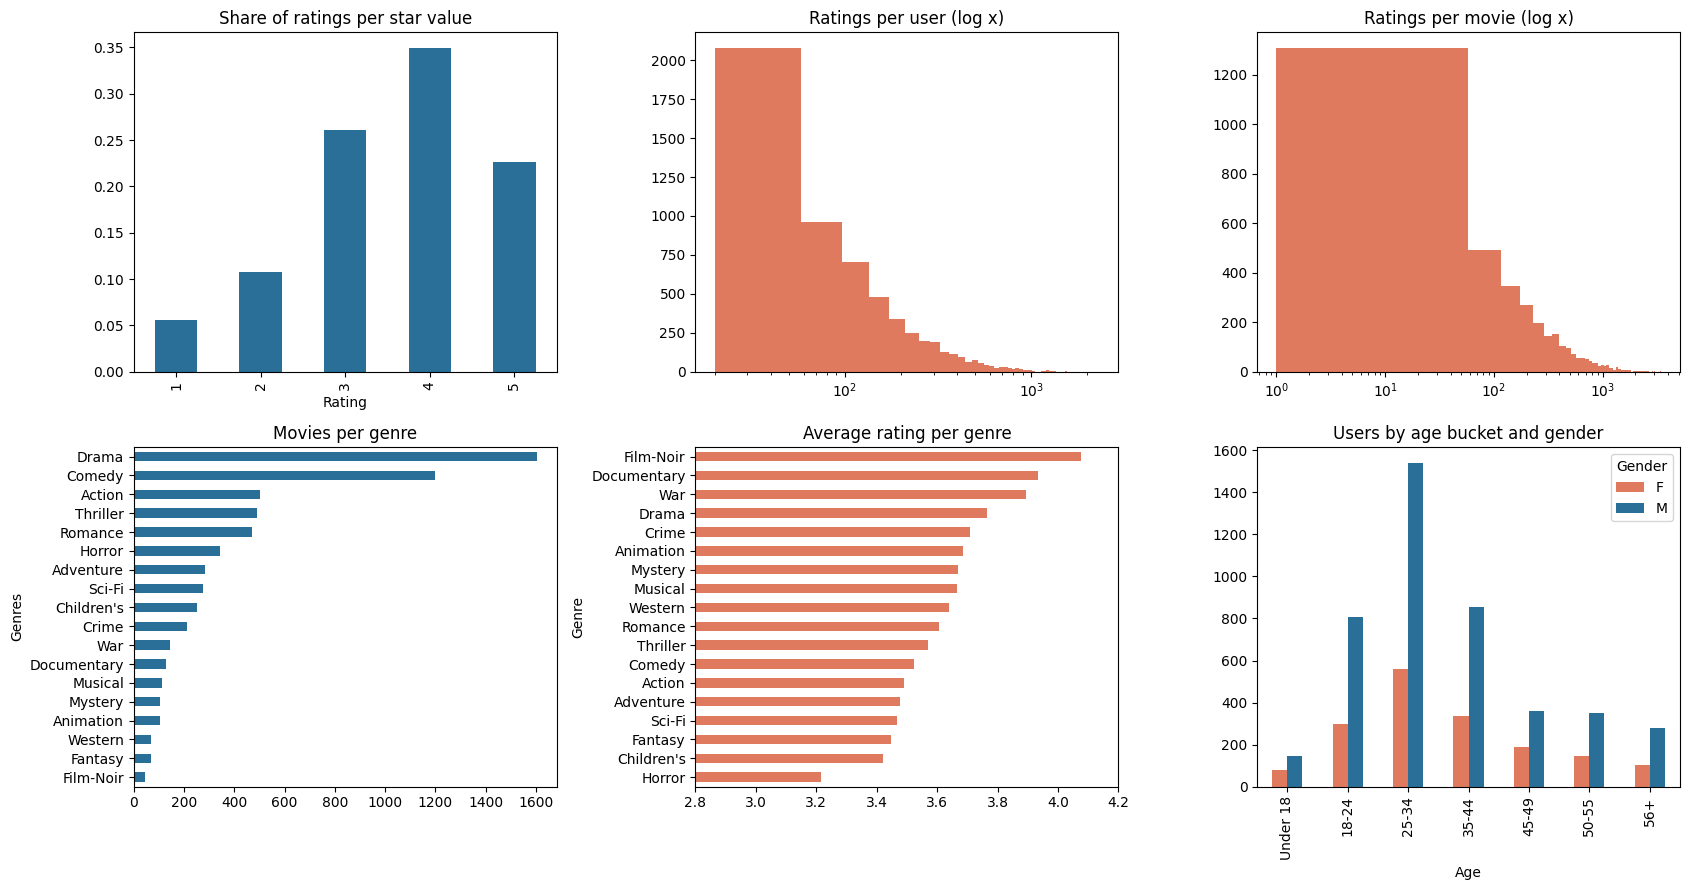

In [ ]:
C_MAIN, C_ALT = "#2a6f97", "#e07a5f"
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
star_share.plot.bar(ax=axes[0, 0], color=C_MAIN, title="Share of ratings per star value")
axes[0, 1].hist(by_user, bins=60, color=C_ALT); axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Ratings per user (log x)")
axes[0, 2].hist(by_movie, bins=60, color=C_ALT); axes[0, 2].set_xscale("log")
axes[0, 2].set_title("Ratings per movie (log x)")
genre_freq.sort_values().plot.barh(ax=axes[1, 0], color=C_MAIN, title="Movies per genre")
genre_avg["mean"].plot.barh(ax=axes[1, 1], color=C_ALT, title="Average rating per genre")
axes[1, 1].set_xlim(2.8, 4.2)
(users_df.groupby(["Age", "Gender"]).size().unstack().rename(index=AGE_LABELS)
 .plot.bar(ax=axes[1, 2], title="Users by age bucket and gender", color=[C_ALT, C_MAIN]))
plt.tight_layout()
plt.show()

In [ ]:
missing = {n: int(f.isna().sum().sum()) for n, f in (("ratings", ratings_df), ("users", users_df), ("movies", movies_df))}
print("Missing cells ->", " | ".join(f"{k}: {v}" for k, v in missing.items()))

Missing cells -> ratings: 0 | users: 0 | movies: 0


In [ ]:
rows_before = len(ratings_df)
ratings_df = ratings_df.drop_duplicates(subset=["UserID", "MovieID"], keep="last")
print(f"Repeated (user, movie) ratings dropped: {rows_before - len(ratings_df)}")
print(f"Repeated UserIDs: {users_df.UserID.duplicated().sum()} | repeated MovieIDs: {movies_df.MovieID.duplicated().sum()} "
      f"| titles shared by several movies: {movies_df.Title.duplicated().sum()}")
users_df = users_df.drop_duplicates("UserID")
movies_df = movies_df.drop_duplicates("MovieID")

Repeated (user, movie) ratings dropped: 0
Repeated UserIDs: 0 | repeated MovieIDs: 0 | titles shared by several movies: 0


In [ ]:
out_of_range = ~ratings_df.Rating.between(1, 5)
print(f"Ratings outside the 1-5 scale (dropped): {int(out_of_range.sum())}")
ratings_df = ratings_df[~out_of_range]
dangling = ~(ratings_df.UserID.isin(users_df.UserID) & ratings_df.MovieID.isin(movies_df.MovieID))
print(f"Ratings pointing to a missing user or movie (dropped): {int(dangling.sum())}")
ratings_df = ratings_df[~dangling].reset_index(drop=True)

Ratings outside the 1-5 scale (dropped): 0
Ratings pointing to a missing user or movie (dropped): 0


In [ ]:
occ_bad = ~users_df.Occupation.isin(list(OCC_NAMES))
age_bad = ~users_df.Age.isin(list(AGE_LABELS))
gender_bad = ~users_df.Gender.isin(["M", "F"])
print(f"Unknown occupation codes: {int(occ_bad.sum())} | unknown age codes: {int(age_bad.sum())} | "
      f"unexpected gender values: {int(gender_bad.sum())}")
users_df.loc[occ_bad, "Occupation"] = 0     # fall back to 'other'

Unknown occupation codes: 0 | unknown age codes: 0 | unexpected gender values: 0


In [ ]:
zip_head = users_df.Zip.astype(str).str.extract(r"(\d{5})")[0]
users_df["Region"] = zip_head.str[0].astype(float).fillna(10).astype(int)   # 0-9 = first zip digit, 10 = unknown
print(f"Zip codes lacking a 5-digit block (region set to 'unknown'): {int(zip_head.isna().sum())}")

Zip codes lacking a 5-digit block (region set to 'unknown'): 0


In [ ]:
title_year = movies_df.Title.str.extract(r"\((\d{4})\)\s*$")[0].astype(float)
no_year_part = movies_df.Title.str.replace(r"\s*\(\d{4}\)\s*$", "", regex=True)
main_title = no_year_part.str.replace(r"\s*\(.*?\)", "", regex=True).str.strip()      # drop alt-language titles
main_title = main_title.str.replace(r"^(.*), (The|A|An)$", r"\2 \1", regex=True)      # 'Matrix, The' -> 'The Matrix'
movies_df["TitleClean"] = main_title
movies_df["Year"] = title_year
print(f"Titles with no year in brackets: {int(movies_df.Year.isna().sum())} (filled with the median year)")
movies_df["Year"] = movies_df.Year.fillna(movies_df.Year.median())
print(f"Release years run from {int(movies_df.Year.min())} to {int(movies_df.Year.max())}")

Titles with no year in brackets: 0 (filled with the median year)
Release years run from 1919 to 2000


In [ ]:
raw_labels = movies_df.Genres.str.split("|")
movies_df["GenreList"] = raw_labels.apply(lambda labels: [g.strip() for g in labels if g.strip() in GENRE_LIST])
stray = set(raw_labels.explode().str.strip()) - set(GENRE_LIST)
print(f"Genre labels outside the 18 official ones: {stray or 'none'} | "
      f"movies that ended up with no genre: {int((movies_df.GenreList.str.len() == 0).sum())}")

Genre labels outside the 18 official ones: none | movies that ended up with no genre: 0


In [ ]:
activity = ratings_df.groupby("UserID").size()
q1, q3 = activity.quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)
print(f"Heavy raters above the IQR fence ({upper_fence:.0f} ratings): {(activity > upper_fence).sum()} users "
      f"(kept - they are genuine; their counts enter the model on a log scale)")
print(f"Clean ratings: {len(ratings_df)}")

Heavy raters above the IQR fence (454 ratings): 475 users (kept - they are genuine; their counts enter the model on a log scale)
Clean ratings: 1000209


In [ ]:
rest_df, test_df = train_test_split(ratings_df, test_size=0.10, random_state=SEED)
train_df, val_df = train_test_split(rest_df, test_size=1 / 9, random_state=SEED)      # -> 80 / 10 / 10
train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
print(f"Random split 80/10/10 -> train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")

Random split 80/10/10 -> train 800167 | val 100021 | test 100021


In [ ]:
users_df = users_df.sort_values("UserID").reset_index(drop=True)
movies_df = movies_df.sort_values("MovieID").reset_index(drop=True)
uid2idx = {uid: k for k, uid in enumerate(users_df.UserID)}
mid2idx = {mid: k for k, mid in enumerate(movies_df.MovieID)}
n_users, n_movies = len(users_df), len(movies_df)
for part in (train_df, val_df, test_df):
    part["u"] = part.UserID.map(uid2idx).astype(np.int64)
    part["m"] = part.MovieID.map(mid2idx).astype(np.int64)

gmean = float(train_df.Rating.mean())
r_train = train_df.Rating.to_numpy(dtype=np.float64)
user_total = np.bincount(train_df.u.to_numpy(), weights=r_train, minlength=n_users)
user_n = np.bincount(train_df.u.to_numpy(), minlength=n_users)
movie_total = np.bincount(train_df.m.to_numpy(), weights=r_train, minlength=n_movies)
movie_n = np.bincount(train_df.m.to_numpy(), minlength=n_movies)

In [ ]:
def attach_mean_features(frame, is_train):
    # Shrunk (Bayesian) mean rating of the user / movie. For training rows the row's own rating is
    # removed first (leave-one-out) so the feature never contains the label it is meant to predict.
    own = frame.Rating.to_numpy(dtype=np.float64) if is_train else 0.0
    removed = 1 if is_train else 0
    u, m = frame.u.to_numpy(), frame.m.to_numpy()
    frame["user_mean"] = (user_total[u] - own + PRIOR_W * gmean) / (user_n[u] - removed + PRIOR_W)
    frame["movie_mean"] = (movie_total[m] - own + PRIOR_W * gmean) / (movie_n[m] - removed + PRIOR_W)


attach_mean_features(train_df, True)
attach_mean_features(val_df, False)
attach_mean_features(test_df, False)

In [ ]:
user_tab = pd.DataFrame({
    "gender_M": (users_df.Gender == "M").astype(float),
    "age": users_df.Age.astype(float),
    "user_cnt_log": np.log1p(user_n),
})
user_cat = users_df[["Occupation", "Region"]].to_numpy(dtype=np.int64)

In [ ]:
mlb = MultiLabelBinarizer(classes=GENRE_LIST)
genre_mat = mlb.fit_transform(movies_df.GenreList).astype(np.float32)

In [ ]:
tfidf = TfidfVectorizer(lowercase=True, stop_words="english", min_df=2, token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b")
title_tfidf = tfidf.fit_transform(movies_df.TitleClean)
n_comp = int(min(SVD_DIMS, title_tfidf.shape[1] - 1))
svd = TruncatedSVD(n_components=n_comp, random_state=SEED)
title_svd = svd.fit_transform(title_tfidf)
print(f"Title vocabulary: {title_tfidf.shape[1]} terms -> {n_comp} SVD dims "
      f"({svd.explained_variance_ratio_.sum():.1%} of variance kept)")

Title vocabulary: 1135 terms -> 20 SVD dims (10.9% of variance kept)


In [ ]:
movie_tab = pd.DataFrame({"year": movies_df.Year.to_numpy(), "movie_cnt_log": np.log1p(movie_n)})
for k in range(n_comp):
    movie_tab[f"svd_{k}"] = title_svd[:, k]

In [ ]:
user_num_cols = ["age", "user_cnt_log"]
movie_num_cols = list(movie_tab.columns)

In [ ]:
user_scaler = StandardScaler().fit(user_tab.iloc[train_df.u.to_numpy()][user_num_cols])
movie_scaler = StandardScaler().fit(movie_tab.iloc[train_df.m.to_numpy()][movie_num_cols])
stat_scaler = StandardScaler().fit(train_df[["user_mean", "movie_mean"]])

In [ ]:
user_num = np.hstack([user_scaler.transform(user_tab[user_num_cols]),
                      user_tab[["gender_M"]].to_numpy()]).astype(np.float32)
movie_num = np.hstack([movie_scaler.transform(movie_tab[movie_num_cols]), genre_mat]).astype(np.float32)
print(f"Numeric columns per user: {user_num.shape[1]} | numeric columns per movie: {movie_num.shape[1]}")

Numeric columns per user: 3 | numeric columns per movie: 40


In [ ]:
ohe = OneHotEncoder(categories=[list(range(21)), list(range(11))], sparse_output=False,
                    handle_unknown="ignore").fit(user_cat)

In [ ]:
def tabular_matrix(frame):
    u, m = frame.u.to_numpy(), frame.m.to_numpy()
    blocks = [user_num[u], movie_num[m], ohe.transform(user_cat[u]),
              stat_scaler.transform(frame[["user_mean", "movie_mean"]])]
    return np.hstack(blocks).astype(np.float32)


X_tr, X_va, X_te = (tabular_matrix(f) for f in (train_df, val_df, test_df))
y_tr, y_va, y_te = (f.Rating.to_numpy(dtype=np.float32) for f in (train_df, val_df, test_df))
print(f"Design matrices -> train {X_tr.shape} | val {X_va.shape} | test {X_te.shape}")

Design matrices -> train (800167, 77) | val (100021, 77) | test (100021, 77)


In [ ]:
experiment_log = []

In [ ]:
def evaluate(y_true, y_pred):
    y_pred = np.clip(y_pred, 1, 5)
    return {"RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE": float(mean_absolute_error(y_true, y_pred)),
            "R2": float(r2_score(y_true, y_pred))}


def record(name, family, pred_val, pred_test, seconds, extra=None):
    v, t = evaluate(y_va, pred_val), evaluate(y_te, pred_test)
    row = {"model": name, "family": family,
           "val_RMSE": v["RMSE"], "val_MAE": v["MAE"], "val_R2": v["R2"],
           "test_RMSE": t["RMSE"], "test_MAE": t["MAE"], "test_R2": t["R2"], "train_sec": seconds}
    row.update(extra or {})
    experiment_log.append(row)
    print(f"  >> {name:<44} val RMSE {v['RMSE']:.4f} | val MAE {v['MAE']:.4f} | {seconds:.0f}s")

In [ ]:
print("\n[Baselines]")
record("Global mean", "baseline", np.full(len(val_df), gmean), np.full(len(test_df), gmean), 0)
additive = lambda f: gmean + (f.user_mean - gmean) + (f.movie_mean - gmean)
record("User mean + movie mean (additive)", "baseline", additive(val_df).to_numpy(), additive(test_df).to_numpy(), 0)


[Baselines]
  >> Global mean                                  val RMSE 1.1188 | val MAE 0.9349 | 0s
  >> User mean + movie mean (additive)            val RMSE 0.9294 | val MAE 0.7309 | 0s


In [ ]:
print("\n[Ridge regression on the engineered features]")
for alpha in (0.5, 5.0, 50.0):
    t0 = time.time()
    ridge = Ridge(alpha=alpha).fit(X_tr, y_tr)
    record(f"Ridge (alpha={alpha:g})", "linear", ridge.predict(X_va), ridge.predict(X_te), time.time() - t0)


[Ridge regression on the engineered features]
  >> Ridge (alpha=0.5)                            val RMSE 0.9204 | val MAE 0.7299 | 2s
  >> Ridge (alpha=5)                              val RMSE 0.9204 | val MAE 0.7299 | 3s
  >> Ridge (alpha=50)                             val RMSE 0.9204 | val MAE 0.7299 | 1s


In [ ]:
print("\n[Histogram gradient boosting on the engineered features]")
hgb_grid = [dict(learning_rate=0.08, max_leaf_nodes=31, max_iter=400),
            dict(learning_rate=0.05, max_leaf_nodes=63, max_iter=600)]
for params in hgb_grid:
    t0 = time.time()
    booster = HistGradientBoostingRegressor(early_stopping=True, n_iter_no_change=15,
                                            random_state=SEED, **params).fit(X_tr, y_tr)
    record(f"HistGB (lr={params['learning_rate']}, leaves={params['max_leaf_nodes']})", "gbm",
           booster.predict(X_va), booster.predict(X_te), time.time() - t0, {"iters": booster.n_iter_})


[Histogram gradient boosting on the engineered features]
  >> HistGB (lr=0.08, leaves=31)                  val RMSE 0.9203 | val MAE 0.7318 | 115s
  >> HistGB (lr=0.05, leaves=63)                  val RMSE 0.9253 | val MAE 0.7361 | 182s


In [ ]:
class MatrixFactorization(nn.Module):
    # rating = global mean + user bias + movie bias + <user vector, movie vector>
    def __init__(self, n_users, n_movies, emb_dim):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.register_buffer("global_mean", torch.tensor(gmean))
        for table in (self.user_emb, self.movie_emb):
            nn.init.normal_(table.weight, std=0.05)
        for table in (self.user_bias, self.movie_bias):
            nn.init.zeros_(table.weight)

    def forward(self, u, m):
        interaction = (self.user_emb(u) * self.movie_emb(m)).sum(dim=1)
        offsets = self.user_bias(u).squeeze(-1) + self.movie_bias(m).squeeze(-1)
        return self.global_mean + offsets + interaction

In [ ]:
class HybridRecommender(nn.Module):
    # Same collaborative core as MatrixFactorization, plus an MLP that sees the side information
    # (occupation / region embeddings, scaled user + movie numeric features, genre flags).
    # The lookup tables live in buffers, so the saved state_dict is fully self-contained.
    def __init__(self, n_users, n_movies, n_user_num, n_movie_num, emb_dim=32, hidden=128, dropout=0.2,
                 n_occ=21, n_reg=11):
        super().__init__()
        self.register_buffer("user_cat", torch.zeros(n_users, 2, dtype=torch.long))
        self.register_buffer("user_num", torch.zeros(n_users, n_user_num))
        self.register_buffer("movie_num", torch.zeros(n_movies, n_movie_num))
        self.register_buffer("global_mean", torch.tensor(0.0))
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.occ_emb = nn.Embedding(n_occ, 8)
        self.reg_emb = nn.Embedding(n_reg, 4)
        width = 2 * emb_dim + 8 + 4 + n_user_num + n_movie_num
        self.mlp = nn.Sequential(
            nn.Linear(width, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )
        for table in (self.user_emb, self.movie_emb, self.occ_emb, self.reg_emb):
            nn.init.normal_(table.weight, std=0.05)
        for table in (self.user_bias, self.movie_bias):
            nn.init.zeros_(table.weight)

    def forward(self, u, m):
        ue, me = self.user_emb(u), self.movie_emb(m)
        occ_id, reg_id = self.user_cat[u].unbind(dim=1)
        side = torch.cat([ue, me, self.occ_emb(occ_id), self.reg_emb(reg_id),
                          self.user_num[u], self.movie_num[m]], dim=1)
        collaborative = (ue * me).sum(dim=1) + self.user_bias(u).squeeze(-1) + self.movie_bias(m).squeeze(-1)
        return self.global_mean + collaborative + self.mlp(side).squeeze(-1)

In [ ]:
as_t = lambda arr, dt: torch.as_tensor(np.asarray(arr, dtype=dt), device=DEVICE)
t_u, t_m, t_y = as_t(train_df.u, np.int64), as_t(train_df.m, np.int64), as_t(y_tr, np.float32)
v_u, v_m = as_t(val_df.u, np.int64), as_t(val_df.m, np.int64)
e_u, e_m = as_t(test_df.u, np.int64), as_t(test_df.m, np.int64)

In [ ]:
@torch.no_grad()
def predict_nn(model, users, movies, chunk=65536):
    model.eval()
    parts = [model(users[i:i + chunk], movies[i:i + chunk]) for i in range(0, len(users), chunk)]
    return torch.cat(parts).clamp(1, 5).cpu().numpy()

In [ ]:
def fit_nn(model, name, lr, wd):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best = {"rmse": float("inf"), "state": None, "epoch": 0}
    stale, curve, started = 0, [], time.time()
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        order = torch.randperm(len(t_u), device=DEVICE)
        sq_err = 0.0
        for start in range(0, len(order), BATCH_SIZE):
            pick = order[start:start + BATCH_SIZE]
            loss = F.mse_loss(model(t_u[pick], t_m[pick]), t_y[pick])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            sq_err += loss.item() * len(pick)
        val_rmse = float(np.sqrt(mean_squared_error(y_va, predict_nn(model, v_u, v_m))))
        curve.append((float(np.sqrt(sq_err / len(order))), val_rmse))
        print(f"    epoch {epoch:02d}   train RMSE {curve[-1][0]:.4f}   val RMSE {val_rmse:.4f}")
        if val_rmse < best["rmse"] - 1e-4:
            best.update(rmse=val_rmse, state=copy.deepcopy(model.state_dict()), epoch=epoch)
            stale = 0
        else:
            stale += 1
            if stale >= PATIENCE:
                print(f"    early stopping - best epoch was {best['epoch']}")
                break
    model.load_state_dict(best["state"])
    record(name, "pytorch", predict_nn(model, v_u, v_m), predict_nn(model, e_u, e_m),
           time.time() - started, {"best_epoch": best["epoch"]})
    return curve

In [ ]:
def make_hybrid(emb, hidden, drop):
    net = HybridRecommender(n_users, n_movies, user_num.shape[1], movie_num.shape[1], emb, hidden, drop)
    net.user_cat.copy_(torch.as_tensor(user_cat))
    net.user_num.copy_(torch.as_tensor(user_num))
    net.movie_num.copy_(torch.as_tensor(movie_num))
    net.global_mean.fill_(gmean)
    return net

In [ ]:
trained_nets, curves = {}, {}
mf_grid = [dict(emb=32, lr=3e-3, wd=0.1), dict(emb=64, lr=3e-3, wd=0.25)]
hybrid_grid = [dict(emb=32, hidden=128, drop=0.25, lr=2e-3, wd=0.08),
               dict(emb=64, hidden=256, drop=0.3, lr=2e-3, wd=0.1),
               dict(emb=48, hidden=192, drop=0.3, lr=2e-3, wd=0.15)]

In [ ]:
for cfg in mf_grid:
    label = f"MF (emb={cfg['emb']}, wd={cfg['wd']})"
    print(f"\n  Training {label}")
    net = MatrixFactorization(n_users, n_movies, cfg["emb"])
    curves[label] = fit_nn(net, label, cfg["lr"], cfg["wd"])
    trained_nets[label] = (net, cfg, "MatrixFactorization")


  Training MF (emb=32, wd=0.1)
    epoch 01   train RMSE 1.0378   val RMSE 0.9592
    epoch 02   train RMSE 0.8993   val RMSE 0.8877
    epoch 03   train RMSE 0.8393   val RMSE 0.8709
    epoch 04   train RMSE 0.7982   val RMSE 0.8664
    epoch 05   train RMSE 0.7665   val RMSE 0.8679
    epoch 06   train RMSE 0.7428   val RMSE 0.8716
    epoch 07   train RMSE 0.7251   val RMSE 0.8753
    epoch 08   train RMSE 0.7117   val RMSE 0.8792
    early stopping - best epoch was 4
  >> MF (emb=32, wd=0.1)                          val RMSE 0.8664 | val MAE 0.6790 | 4s

  Training MF (emb=64, wd=0.25)
    epoch 01   train RMSE 1.0337   val RMSE 0.9437
    epoch 02   train RMSE 0.8832   val RMSE 0.8814
    epoch 03   train RMSE 0.8162   val RMSE 0.8650
    epoch 04   train RMSE 0.7637   val RMSE 0.8623
    epoch 05   train RMSE 0.7220   val RMSE 0.8650
    epoch 06   train RMSE 0.6904   val RMSE 0.8687
    epoch 07   train RMSE 0.6668   val RMSE 0.8725
    epoch 08   train RMSE 0.6490   val RMSE 

In [ ]:
for cfg in hybrid_grid:
    label = f"Hybrid NN (emb={cfg['emb']}, h={cfg['hidden']}, drop={cfg['drop']}, wd={cfg['wd']})"
    print(f"\n  Training {label}")
    net = make_hybrid(cfg["emb"], cfg["hidden"], cfg["drop"])
    curves[label] = fit_nn(net, label, cfg["lr"], cfg["wd"])
    trained_nets[label] = (net, cfg, "HybridRecommender")


  Training Hybrid NN (emb=32, h=128, drop=0.25, wd=0.08)
    epoch 01   train RMSE 0.9490   val RMSE 0.9050
    epoch 02   train RMSE 0.8965   val RMSE 0.8897
    epoch 03   train RMSE 0.8786   val RMSE 0.8767
    epoch 04   train RMSE 0.8600   val RMSE 0.8657
    epoch 05   train RMSE 0.8440   val RMSE 0.8621
    epoch 06   train RMSE 0.8306   val RMSE 0.8566
    epoch 07   train RMSE 0.8182   val RMSE 0.8546
    epoch 08   train RMSE 0.8072   val RMSE 0.8537
    epoch 09   train RMSE 0.7976   val RMSE 0.8533
    epoch 10   train RMSE 0.7885   val RMSE 0.8539
    epoch 11   train RMSE 0.7793   val RMSE 0.8556
    epoch 12   train RMSE 0.7705   val RMSE 0.8568
    epoch 13   train RMSE 0.7620   val RMSE 0.8580
    early stopping - best epoch was 9
  >> Hybrid NN (emb=32, h=128, drop=0.25, wd=0.08) val RMSE 0.8533 | val MAE 0.6659 | 10s

  Training Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)
    epoch 01   train RMSE 0.9398   val RMSE 0.8991
    epoch 02   train RMSE 0.8862   val RMSE 

In [ ]:
leaderboard = pd.DataFrame(experiment_log).sort_values("val_RMSE").reset_index(drop=True)
leaderboard.to_csv(f"{ARTIFACT_DIR}/experiment_results.csv", index=False)
show_cols = ["model", "val_RMSE", "val_MAE", "val_R2", "test_RMSE", "test_MAE", "test_R2", "train_sec"]
print(leaderboard[show_cols].round(4).to_string(index=False))

                                        model  val_RMSE  val_MAE  val_R2  test_RMSE  test_MAE  test_R2  train_sec
  Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)    0.8513   0.6650  0.4210     0.8511    0.6650   0.4179     8.0025
 Hybrid NN (emb=48, h=192, drop=0.3, wd=0.15)    0.8529   0.6661  0.4188     0.8507    0.6644   0.4185     9.4700
Hybrid NN (emb=32, h=128, drop=0.25, wd=0.08)    0.8533   0.6659  0.4183     0.8515    0.6656   0.4175    10.2655
                         MF (emb=64, wd=0.25)    0.8623   0.6768  0.4059     0.8611    0.6768   0.4042     3.7306
                          MF (emb=32, wd=0.1)    0.8664   0.6790  0.4002     0.8668    0.6803   0.3962     3.9196
                  HistGB (lr=0.08, leaves=31)    0.9203   0.7318  0.3233     0.9209    0.7325   0.3186   114.8477
                              Ridge (alpha=5)    0.9204   0.7299  0.3232     0.9211    0.7310   0.3183     2.5830
                            Ridge (alpha=0.5)    0.9204   0.7299  0.3232     0.9211    0

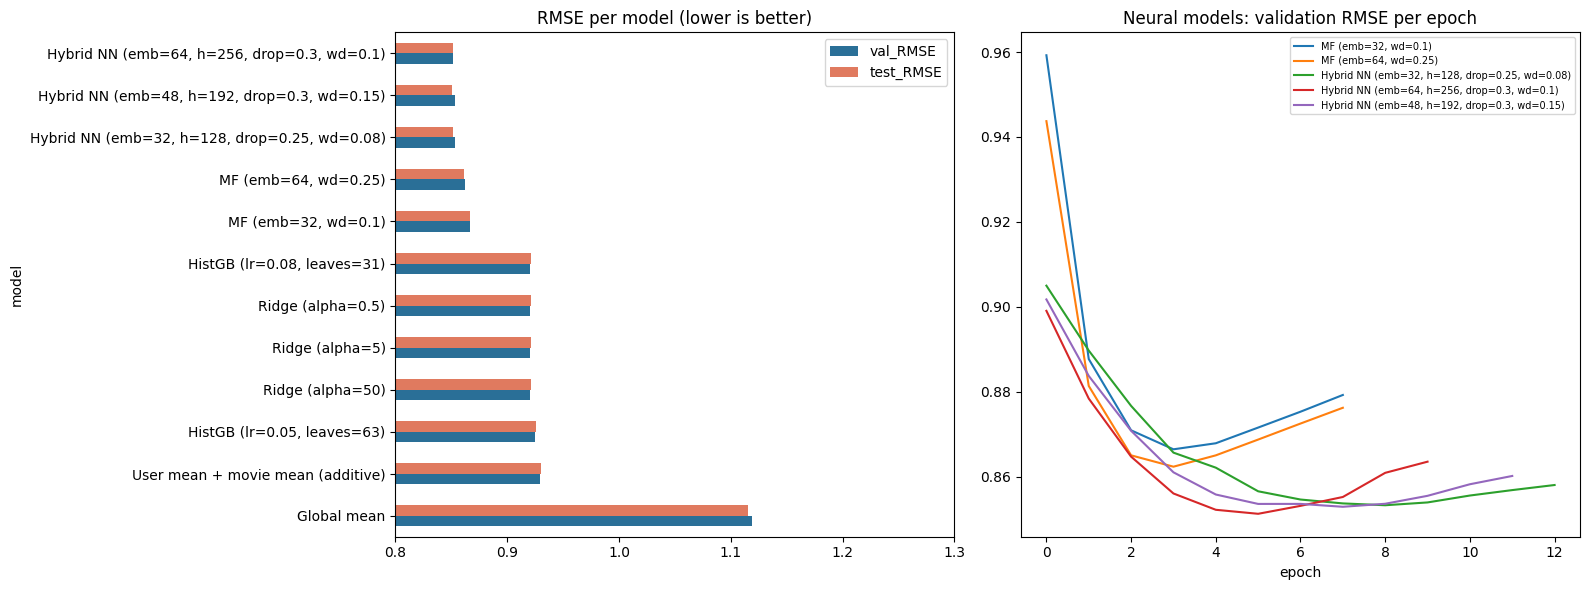

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
(leaderboard.sort_values("val_RMSE", ascending=False)
 .plot.barh(x="model", y=["val_RMSE", "test_RMSE"], ax=axes[0], color=[C_MAIN, C_ALT]))
axes[0].set_xlim(0.8, 1.3)
axes[0].set_title("RMSE per model (lower is better)")
for label, curve in curves.items():
    axes[1].plot([v for _, v in curve], label=label)
axes[1].set_title("Neural models: validation RMSE per epoch")
axes[1].set_xlabel("epoch")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
winner = leaderboard.iloc[0]
print(f"\nLowest validation RMSE overall: {winner.model}")


Lowest validation RMSE overall: Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)


In [ ]:
nn_board = leaderboard[leaderboard.family == "pytorch"]
best_name = nn_board.iloc[0].model
best_model, best_cfg, best_cls = trained_nets[best_name]
print(f"Candidate for deployment: {best_name}")

Candidate for deployment: Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)


In [ ]:
final = leaderboard[leaderboard.model == best_name].iloc[0]
print(f"\nHELD-OUT TEST RESULT ({best_name}): RMSE {final.test_RMSE:.4f} | MAE {final.test_MAE:.4f} | R2 {final.test_R2:.4f}")


HELD-OUT TEST RESULT (Hybrid NN (emb=64, h=256, drop=0.3, wd=0.1)): RMSE 0.8511 | MAE 0.6650 | R2 0.4179


In [ ]:
# The serving app needs the model that carries the side information, so plain MF is never deployed.
if best_cls != "HybridRecommender":
    best_name = nn_board[nn_board.model.str.startswith("Hybrid")].iloc[0].model
    best_model, best_cfg, best_cls = trained_nets[best_name]
    final = leaderboard[leaderboard.model == best_name].iloc[0]
    print(f"(Plain MF ranked first; deploying the best hybrid instead: {best_name})")
    print(f"TEST RESULT: RMSE {final.test_RMSE:.4f} | MAE {final.test_MAE:.4f} | R2 {final.test_R2:.4f}")

In [ ]:
best_model.cpu().eval()
torch.save(best_model.state_dict(), f"{ARTIFACT_DIR}/model.pt")
config = {
    "model_name": best_name, "architecture": best_cls,
    "n_users": n_users, "n_movies": n_movies,
    "n_user_num": int(user_num.shape[1]), "n_movie_num": int(movie_num.shape[1]),
    "emb_dim": best_cfg["emb"], "hidden": best_cfg["hidden"], "dropout": best_cfg["drop"],
    "global_mean": gmean,
    "metrics": {k: float(final[k]) for k in ("val_RMSE", "test_RMSE", "test_MAE", "test_R2")},
}
with open(f"{ARTIFACT_DIR}/model_config.json", "w") as fh:
    json.dump(config, fh, indent=2)
saved_to = joblib.dump({
    "genre_binarizer": mlb, "title_tfidf": tfidf, "title_svd": svd,
    "user_scaler": user_scaler, "movie_scaler": movie_scaler, "stat_scaler": stat_scaler,
    "onehot_occ_region": ohe, "uid2idx": uid2idx, "mid2idx": mid2idx,
}, f"{ARTIFACT_DIR}/preprocessing.joblib")
print("Model + preprocessing written:", saved_to)

Model + preprocessing written: ['artifacts/preprocessing.joblib']


In [ ]:
rating_counts = ratings_df.groupby("UserID").size()
users_lookup = users_df.assign(
    AgeGroup=users_df.Age.map(AGE_LABELS),
    OccupationName=users_df.Occupation.map(OCC_NAMES),
    n_ratings=users_df.UserID.map(rating_counts).fillna(0).astype(int),
    u_idx=np.arange(n_users),
)
users_lookup[["UserID", "u_idx", "Gender", "AgeGroup", "OccupationName", "n_ratings"]].to_csv(
    f"{ARTIFACT_DIR}/users_lookup.csv", index=False)

movies_lookup = pd.DataFrame({
    "MovieID": movies_df.MovieID,
    "m_idx": np.arange(n_movies),
    "Title": movies_df.TitleClean,
    "Year": movies_df.Year.astype(int),
    "Genres": movies_df.Genres,
    "train_count": movie_n,
    "avg_rating": np.where(movie_n > 0, movie_total / np.maximum(movie_n, 1), np.nan),
})
movies_lookup.to_csv(f"{ARTIFACT_DIR}/movies_lookup.csv", index=False)
ratings_df[["UserID", "MovieID", "Rating"]].to_csv(f"{ARTIFACT_DIR}/ratings_clean.csv.gz", index=False)
print(f"Artifacts in ./{ARTIFACT_DIR}: " + ", ".join(sorted(os.listdir(ARTIFACT_DIR))))

Artifacts in ./artifacts: experiment_results.csv, model.pt, model_config.json, movies_lookup.csv, preprocessing.joblib, ratings_clean.csv.gz, users_lookup.csv
